In [32]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [33]:
class AgentState(TypedDict):
  player_name: str
  guesses: List[int]
  attempts: int
  lower_bound: int
  upper_bound: int
  answer:int
  max_limit: int

In [34]:
def start_node(state: AgentState)->dict:
  answer = random.randint(state['lower_bound'],state['upper_bound'])
  print("Answer:",answer)
  return {
    "player_name": state['player_name'],
    "answer": answer,
    "attempts":0,
    "max_limit":7,
    "guesses": [],
    "upper_bound":state['upper_bound'],
    "lower_bound":state['lower_bound'],
  }
  # second_graph.add_node("router", lambda state: {})
def make_guess(state: AgentState)->dict:
  new_guess = random.randint(state["lower_bound"], state["upper_bound"])
  attempts = state['attempts'] + 1
  print("Attempts", attempts)
  print(f"Guess number:{new_guess}")

  return {
    "attempts": attempts,
    "guesses" :  state["guesses"] + [new_guess]
  }

def hint_node(state: AgentState)->dict:

  guess = state['guesses'][-1]
  answer = state['answer']
  upper_bound = state['upper_bound']
  lower_bound = state['lower_bound']
  if guess > answer:
    print(f"Guess smaller, set upper bound to {guess}")
    upper_bound = guess -1
  if guess < answer:
    print(f"Guess Bigger, set lower bound to {guess}")
    lower_bound = guess +1

  return {
    "upper_bound": upper_bound,
    "lower_bound": lower_bound
  }

def guessing_condition(state: AgentState)->str:

  if state['attempts'] > state['max_limit']:
    print("Max Attempt")
    return 'exit'
  elif state['answer'] == state['guesses'][-1]:
    print("Corrent Answer!")
    return 'exit'
  else:
    return 'loop'



In [35]:
graph = StateGraph(AgentState)

graph.add_node("start_node", start_node)
graph.add_node("make_guess", make_guess)
graph.add_node("hint_node", hint_node)

graph.add_edge("start_node", "make_guess")
graph.add_edge("make_guess", "hint_node")

graph.add_conditional_edges(
  "hint_node",
  guessing_condition,
  {
    "loop": "make_guess",
    "exit": END
  }
)

graph.set_entry_point("start_node")
app = graph.compile()

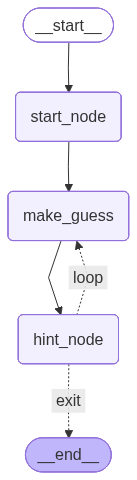

In [36]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [37]:
result = app.invoke({
    "player_name": "Wei",
    "lower_bound": 1,
    "upper_bound": 10
})

print(result)

Answer: 4
Attempts 1
Guess number:2
Guess Bigger, set lower bound to 2
Attempts 2
Guess number:8
Guess smaller, set upper bound to 8
Attempts 3
Guess number:4
Corrent Answer!
{'player_name': 'Wei', 'guesses': [2, 8, 4], 'attempts': 3, 'lower_bound': 3, 'upper_bound': 7, 'answer': 4, 'max_limit': 7}
